# Composure

**Composure** measures how well a pitcher maintains their composure in a variety of unfortunate situations.

The score is an aggregation of 14 component statistics, each measuring the rate of an undesirable outcome (walk, ball) following a specific trigger event. All components are normalized within the season and inverted so that **higher = better composure**. Composure+ acts as any other *plus* metric, normalizing player results where a Composure+ of 100 is league average

## Notebook structure

| Phase | What runs | Re-run when... |
|---|---|---|
| **0 — Config** | Thresholds, weights, normalization method | Any parameter change |
| **1 — Data pull** | Fetch pitch-by-pitch from Baseball Savant | New season / first run  |
| **2 — Metric computation** | Compute raw per-pitcher rates from parquet | Changing thresholds or metric definitions |
| **3 — Scoring** | Apply weights + normalization, save results | Changing weights or normalization only |
| **4 — Analysis** | YoY repeatability, component heatmap, quadrant scatter, external validation | Any time results change |

---
## Metric Definitions

Each metric is a **conditional rate**: given that event X occurred in the previous plate appearance (or the previous pitch), how often does the pitcher produce outcome Y?

---

### After Hard Contact — walks

| Metric | Trigger | Outcome | Intuition |
|---|---|---|---|
| `walk_after_barrel` | Previous PA: barrel hit (`launch_speed_angle == 6`) | Next PA: walk or HBP | Did giving up the hardest possible contact cause a loss of command? |
| `walk_after_hard_hit` | Previous PA: exit velo ≥ `HARD_HIT_MPH` (default 90 mph) | Next PA: walk or HBP | Broader hard-contact trigger — any well-struck ball |
| `walk_after_high_xba` | Previous PA: xBa ≥ `HIGH_XBA` (default .450) | Next PA: walk or HBP | Quality-of-contact trigger using expected stats rather than raw velo |

### After Hard Contact — immediate balls

| Metric | Trigger | Outcome | Intuition |
|---|---|---|---|
| `first_ball_after_barrel` | Previous PA: barrel | First pitch of next PA: ball | Quickest possible composure check — did the pitcher come out attacking? |
| `first_ball_after_hard_hit` | Previous PA: exit velo ≥ `HARD_HIT_MPH` | First pitch of next PA: ball | Same idea, broader hard-contact trigger |
| `first_ball_after_high_xba` | Previous PA: xBa ≥ `HIGH_XBA` | First pitch of next PA: ball | Expected-stats version |

---

### After Unlucky Soft Contact — walks
Soft contact is considered *unlucky* based on the expected batting average (xBA) of an event

| Metric | Trigger | Outcome |
|---|---|---
| `walk_after_soft_hit` | Previous PA: exit velo < `SOFT_HIT_MPH` (default 80 mph) | Next PA: walk or HBP |
| `walk_after_low_xba` | Previous PA: xBa < `LOW_XBA` (default .300) | Next PA: walk or HBP |

### After Unlucky Soft Contact — immediate balls

| Metric | Trigger | Outcome |
|---|---|---|
| `first_ball_after_soft_hit` | Previous PA: exit velo < `SOFT_HIT_MPH` | First pitch of next PA: ball |
| `first_ball_after_low_xba` | Previous PA: xBa < `LOW_XBA` | First pitch of next PA: ball |

---

### Additional Metrics

| Metric | Trigger | Outcome |
|---|---|---|
| `hard_hit_after_walk` | Previous PA: walk or HBP | Next PA: exit velo ≥ `HARD_HIT_MPH` |
| `hard_hit_after_soft` | Previous PA: exit velo < `SOFT_HIT_MPH` | Next PA: exit velo ≥ `HARD_HIT_MPH` |
| `walk_after_walk` | Previous PA: walk or HBP | Next PA: walk or HBP |
| `ball_after_foul` | Current PA: foul on pitch N | Pitch N+1 (same PA): ball |

---

### Classification rules
- **Barrel** = `launch_speed_angle == 6` (Based on the statcast classification)
- **Foul tip** → excluded from `ball_after_foul` trigger

---
## Phase 0 — Config & Setup

In [415]:
%pip install pybaseball

Note: you may need to restart the kernel to use updated packages.


In [416]:
import os, requests
import pandas as pd
import numpy as np
from tqdm import tqdm
import pybaseball
from pybaseball import statcast_single_game, playerid_reverse_lookup, pitching_stats
import warnings
warnings.filterwarnings('ignore')
pybaseball.cache.enable()

import subprocess
_git_root = subprocess.check_output(["git", "rev-parse", "--show-toplevel"], cwd=os.path.abspath(".")).decode().strip()
_nb_dir = os.path.join(_git_root, "composure")
DATA_DIR = os.path.join(_nb_dir, "data")
RESULTS_DIR = os.path.join(_nb_dir, "results")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

SEASONS = [2021, 2022, 2023, 2024, 2025]

# ── Metric thresholds (re-run Phase 2 if you change these) ───────────────────
HARD_HIT_MPH  = 100     
SOFT_HIT_MPH  = 85    
HIGH_XBA      = 0.550  
LOW_XBA       = 0.250

# ── Pitcher qualification ─────────────────────────────────────────────────────
MIN_PITCHES = 500      # pitchers below this threshold are excluded from scoring

# ── Per-metric weights (re-run Phase 3 if you change these) ──────────────────
# Default 1.0 = equal contribution. Set to 0 to exclude a metric entirely.

# because walks are more impactful & indicative of composure, they have the highest weights,
# followed by the immediate ball result following an unlucky situation

WEIGHTS = {
    # After hard contact
    'walk_after_barrel':          2.0,
    'walk_after_hard_hit':        1.5,
    'walk_after_high_xba':        1.5,
    'first_ball_after_barrel':    0.5,
    'first_ball_after_hard_hit':  0.5,
    'first_ball_after_high_xba':  0.5,
    # After unlucky soft contact
    'walk_after_soft_hit':        2.5,
    'walk_after_low_xba':         2.5,
    'first_ball_after_soft_hit':  0.5,
    'first_ball_after_low_xba':   0.5,
    # Additional
    'hard_hit_after_walk':        0.25, # hard hits have additional context, should not be weighed as heavily
    'hard_hit_after_soft':        0.25,
    'walk_after_walk':            1.75, # back to back walks are a large indication of composure dropping
    'ball_after_foul':            .05,
}

METRIC_COLS = list(WEIGHTS.keys())

# ── Sub-score groupings (re-run Phase 3 if you change these) ─────────────────
# Adversity: after hard contact / walks — does the pitcher compound the damage?
ADVERSITY_METRICS = [
    'walk_after_barrel', 'walk_after_hard_hit', 'walk_after_high_xba',
    'first_ball_after_barrel', 'first_ball_after_hard_hit', 'first_ball_after_high_xba',
    'walk_after_walk', 'hard_hit_after_walk',
]
# Momentum: after lucky / soft contact — does the pitcher coast or stay sharp?
MOMENTUM_METRICS = [
    'walk_after_soft_hit', 'walk_after_low_xba',
    'first_ball_after_soft_hit', 'first_ball_after_low_xba',
    'hard_hit_after_soft', 'ball_after_foul',
]
# How to weight the two sub-scores when combining into overall composure_plus
ADVERSITY_WEIGHT = 1.0
MOMENTUM_WEIGHT  = 1.0

# ── Normalization method (re-run Phase 3 if you change this) ─────────────────
# 'zscore'     — (x - mean) / std across pitchers in the season
# 'percentile' — rank-based 0–1 percentile across pitchers
# 'minmax'     — rescale each metric to [0, 1] across pitchers
NORMALIZATION = 'zscore'

# ── Sample-size shrinkage (re-run Phase 3 if you change this) ────────────────
# Pseudo-observations added at the league average rate per metric group.
# Higher value = stronger pull toward league average for low-sample pitchers.
# Adversity triggers (barrels, hard hits) are rare → need stronger shrinkage.
# Momentum triggers (soft contact, fouls) are frequent → lighter shrinkage.
PRIOR_OBS_ADV = 40
PRIOR_OBS_MOM = 20

# ── Score confidence scaling (re-run Phase 3 if you change this) ─────────────
# Pitch count at which a pitcher reaches 50% confidence in their score.
# Below this: score pulled toward 100. Above: score stretches toward extremes.
# Raise to be more conservative; lower to trust smaller samples sooner.
SCORE_SCALE      = 40    # spread at full confidence: top pitcher ≈ 100 + z*SCORE_SCALE
CONFIDENCE_PRIOR = 1000  # pitch count at which confidence = 0.5; higher = more conservative

print(f'Config loaded. Data dir: {DATA_DIR}')
print(f'Normalization: {NORMALIZATION} | MIN_PITCHES: {MIN_PITCHES}')
print(f'Thresholds — hard hit: >={HARD_HIT_MPH} mph | soft: <{SOFT_HIT_MPH} mph | '
      f'high xBa: >={HIGH_XBA} | low xBa: <{LOW_XBA}')


Config loaded. Data dir: /Users/aryankapoor/Projects/Baseball/baseball/composure/data
Normalization: zscore | MIN_PITCHES: 500
Thresholds — hard hit: >=100 mph | soft: <85 mph | high xBa: >=0.55 | low xBa: <0.25


---
## Phase 1 — Data Pull

Fetches pitch-by-pitch Statcast data for each season via `pybaseball.statcast_single_game()` and saves the result to `data/all_pitches_YYYY.parquet`.

In [417]:
# ── Shared fetch helpers ──────────────────────────────────────────────────────

KEEP_COLS = [
    'game_pk', 'game_date', 'pitcher', 'player_name',  # player_name = batter
    'at_bat_number', 'pitch_number',
    'pitch_type', 'pitch_name', 'description', 'events',
    'launch_speed',            
    'launch_speed_angle',        
    'estimated_ba_using_speedangle', 
    'release_speed',
]
NUMERIC_COLS = [
    'launch_speed', 'launch_speed_angle', 'estimated_ba_using_speedangle',
    'at_bat_number', 'pitch_number', 'game_pk', 'release_speed',
]

def _normalize_raw(df):
    df = df[[c for c in KEEP_COLS if c in df.columns]].copy()
    for col in NUMERIC_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    # game_date arrives as raw strings and may be mixed with NaN floats across
    # games — coerce to datetime so pyarrow can serialize the parquet cleanly.
    if 'game_date' in df.columns:
        df['game_date'] = pd.to_datetime(df['game_date'], errors='coerce')
    return df

def _fetch_game(game_pk):
    try:
        df = statcast_single_game(game_pk)
        return _normalize_raw(df) if (df is not None and not df.empty) else None
    except Exception as e:
        print(f'  Error {game_pk}: {e}')
        return None

def _get_game_pks(season):
    """Fetch all completed regular-season gamePks from the MLB Stats API."""
    teams = requests.get('https://statsapi.mlb.com/api/v1/teams?sportId=1').json()['teams']
    pks = set()
    for team in tqdm(teams, desc=f'{season} schedule', leave=False):
        sched = requests.get(
            f'https://statsapi.mlb.com/api/v1/schedule'
            f'?sportId=1&season={season}&teamId={team["id"]}&gameType=R'
        ).json()
        for date in sched.get('dates', []):
            for game in date.get('games', []):
                if game.get('status', {}).get('abstractGameState') == 'Final':
                    pks.add(game['gamePk'])
    return sorted(pks)

def pull_season(season):
    """Load pitch data from parquet cache if available, otherwise fetch and save."""
    path = os.path.join(DATA_DIR, f'all_pitches_{season}.parquet')
    if os.path.exists(path):
        df = pd.read_parquet(path)
        print(f'{season}: loaded {len(df):,} pitches from cache.')
        return df
    pks = _get_game_pks(season)
    print(f'{season}: fetching {len(pks)} games...')
    results = [_fetch_game(pk) for pk in tqdm(pks, desc=str(season))]
    dfs = [r for r in results if r is not None]
    print(f'  {len(dfs)} ok / {len(pks) - len(dfs)} failed')
    df = pd.concat(dfs, ignore_index=True)
    df.to_parquet(path, index=False)
    print(f'  Saved → {path}')
    return df

print('Fetch helpers defined.')

Fetch helpers defined.


In [418]:
# ── 2021 data pull ────────────────────────────────────────────────────────────
pitches_2021 = pull_season(2021)

2021: loaded 712,320 pitches from cache.


In [419]:
# ── 2022 data pull ────────────────────────────────────────────────────────────
pitches_2022 = pull_season(2022)

2022: loaded 709,589 pitches from cache.


In [420]:
# ── 2023 data pull ────────────────────────────────────────────────────────────
pitches_2023 = pull_season(2023)

2023: loaded 720,684 pitches from cache.


In [421]:
# ── 2024 data pull ────────────────────────────────────────────────────────────
pitches_2024 = pull_season(2024)

2024: loaded 711,898 pitches from cache.


In [422]:
# ── 2025 data pull ────────────────────────────────────────────────────────────
pitches_2025 = pull_season(2025)

2025: loaded 712,528 pitches from cache.


---
## Phase 2 — Metric Computation

In [ ]:
# ── Shared metric helpers ─────────────────────────────────────────────────────

def _add_flags(df):
    d = df.copy()
    # Pitch outcome flags
    d['is_ball']     = d['description'].isin(
                           ['ball', 'ball_in_dirt', 'blocked_ball', 'pitchout', 'intent_ball'])
    d['is_walk']     = d['events'].isin(['walk', 'hit_by_pitch'])  # HBP counts as walk
    d['is_foul']     = d['description'] == 'foul'                  # foul_tip excluded
    # Contact quality flags (NaN launch_speed → False)
    d['is_hard_hit'] = d['launch_speed'] >= HARD_HIT_MPH
    d['is_soft_hit'] = d['launch_speed'] <  SOFT_HIT_MPH
    d['is_barrel_flag'] = (d['launch_speed_angle'] == 6
                           if 'launch_speed_angle' in d.columns else False)
    d['is_high_xba'] = d['estimated_ba_using_speedangle'] >= HIGH_XBA
    d['is_low_xba']  = d['estimated_ba_using_speedangle'] <  LOW_XBA
    # Filled version used for hard_hit_after_* metrics
    d['is_hard_hit_filled'] = d['is_hard_hit'].fillna(False)
    return d

def _pa_summary(pitches):
    p   = pitches.sort_values(['game_pk', 'at_bat_number', 'pitch_number']).reset_index(drop=True)
    grp = ['game_pk', 'pitcher', 'at_bat_number']
    last  = p.groupby(grp).last().reset_index()
    first = (p.groupby(grp)['is_ball'].first()
              .reset_index()
              .rename(columns={'is_ball': 'first_pitch_is_ball'}))
    cols = [
        'game_pk', 'pitcher', 'at_bat_number',
        'is_walk', 'is_hard_hit', 'is_soft_hit', 'is_barrel_flag',
        'is_high_xba', 'is_low_xba', 'is_hard_hit_filled',
    ]
    return last[cols].merge(first, on=grp, how='left')

def _cross_pa_metrics(pa):
    pa = pa.sort_values(['game_pk', 'pitcher', 'at_bat_number']).reset_index(drop=True)
    trigger_cols = ['is_walk', 'is_hard_hit', 'is_soft_hit', 'is_barrel_flag',
                    'is_high_xba', 'is_low_xba']
    prev = (
        pa.groupby(['game_pk', 'pitcher'])[trigger_cols]
          .shift(1)
          .rename(columns={c: f'prev_{c}' for c in trigger_cols})
    )
    pa = pd.concat([pa, prev], axis=1)

    def rate(trigger, outcome):
        return pa[pa[trigger] == True].groupby('pitcher')[outcome].mean()

    def count(trigger, outcome):
        return pa[pa[trigger] == True].groupby('pitcher')[outcome].count()

    return pd.DataFrame({
        # ── After hard contact ────────────────────────────────────────────
        'walk_after_barrel':            rate('prev_is_barrel_flag', 'is_walk'),
        'walk_after_barrel_n':          count('prev_is_barrel_flag', 'is_walk'),
        'walk_after_hard_hit':          rate('prev_is_hard_hit',    'is_walk'),
        'walk_after_hard_hit_n':        count('prev_is_hard_hit',    'is_walk'),
        'walk_after_high_xba':          rate('prev_is_high_xba',    'is_walk'),
        'walk_after_high_xba_n':        count('prev_is_high_xba',    'is_walk'),
        'first_ball_after_barrel':      rate('prev_is_barrel_flag', 'first_pitch_is_ball'),
        'first_ball_after_barrel_n':    count('prev_is_barrel_flag', 'first_pitch_is_ball'),
        'first_ball_after_hard_hit':    rate('prev_is_hard_hit',    'first_pitch_is_ball'),
        'first_ball_after_hard_hit_n':  count('prev_is_hard_hit',    'first_pitch_is_ball'),
        'first_ball_after_high_xba':    rate('prev_is_high_xba',    'first_pitch_is_ball'),
        'first_ball_after_high_xba_n':  count('prev_is_high_xba',    'first_pitch_is_ball'),
        # ── After unlucky soft contact ────────────────────────────────────
        'walk_after_soft_hit':          rate('prev_is_soft_hit',    'is_walk'),
        'walk_after_soft_hit_n':        count('prev_is_soft_hit',    'is_walk'),
        'walk_after_low_xba':           rate('prev_is_low_xba',     'is_walk'),
        'walk_after_low_xba_n':         count('prev_is_low_xba',     'is_walk'),
        'first_ball_after_soft_hit':    rate('prev_is_soft_hit',    'first_pitch_is_ball'),
        'first_ball_after_soft_hit_n':  count('prev_is_soft_hit',    'first_pitch_is_ball'),
        'first_ball_after_low_xba':     rate('prev_is_low_xba',     'first_pitch_is_ball'),
        'first_ball_after_low_xba_n':   count('prev_is_low_xba',     'first_pitch_is_ball'),
        # ── Additional ───────────────────────────────────────────────────
        'hard_hit_after_walk':          rate('prev_is_walk',        'is_hard_hit_filled'),
        'hard_hit_after_walk_n':        count('prev_is_walk',        'is_hard_hit_filled'),
        'hard_hit_after_soft':          rate('prev_is_soft_hit',    'is_hard_hit_filled'),
        'hard_hit_after_soft_n':        count('prev_is_soft_hit',    'is_hard_hit_filled'),
        'walk_after_walk':              rate('prev_is_walk',        'is_walk'),
        'walk_after_walk_n':            count('prev_is_walk',        'is_walk'),
    })

def _ball_after_foul(pitches):
    p = pitches.sort_values(['game_pk', 'pitcher', 'at_bat_number', 'pitch_number']).reset_index(drop=True)
    p['prev_is_foul'] = p.groupby(['game_pk', 'pitcher', 'at_bat_number'])['is_foul'].shift(1)
    grp = p[p['prev_is_foul'] == True].groupby('pitcher')['is_ball']
    return pd.DataFrame({
        'ball_after_foul':   grp.mean(),
        'ball_after_foul_n': grp.count(),
    })

def compute_metrics(season):
    pitches_path = os.path.join(DATA_DIR, f'all_pitches_{season}.parquet')
    if not os.path.exists(pitches_path):
        raise FileNotFoundError(f'Run the Phase 1 pull cell for {season} first.')

    print(f'{season}: loading pitches...')
    pitches = _add_flags(pd.read_parquet(pitches_path))

    print(f'{season}: computing metrics...')
    pa      = _pa_summary(pitches)
    metrics = _cross_pa_metrics(pa).join(_ball_after_foul(pitches), how='outer')
    metrics = metrics.join(pitches.groupby('pitcher').size().rename('pitch_count'))

    out = os.path.join(DATA_DIR, f'pitcher_metrics_{season}.parquet')
    metrics.to_parquet(out)
    print(f'{season}: {len(metrics)} pitchers saved → {out}')
    return metrics

print('Metric helpers defined.')


In [424]:
# ── 2021 metric computation ───────────────────────────────────────────────────
metrics_2021 = compute_metrics(2021)

2021: loading pitches...
2021: computing metrics...
2021: 909 pitchers saved → /Users/aryankapoor/Projects/Baseball/baseball/composure/data/pitcher_metrics_2021.parquet


In [425]:
# ── 2022 metric computation ───────────────────────────────────────────────────
metrics_2022 = compute_metrics(2022)

2022: loading pitches...
2022: computing metrics...
2022: 871 pitchers saved → /Users/aryankapoor/Projects/Baseball/baseball/composure/data/pitcher_metrics_2022.parquet


In [426]:
# ── 2023 metric computation ───────────────────────────────────────────────────
metrics_2023 = compute_metrics(2023)

2023: loading pitches...
2023: computing metrics...
2023: 863 pitchers saved → /Users/aryankapoor/Projects/Baseball/baseball/composure/data/pitcher_metrics_2023.parquet


In [427]:
# ── 2024 metric computation ───────────────────────────────────────────────────
metrics_2024 = compute_metrics(2024)

2024: loading pitches...
2024: computing metrics...
2024: 855 pitchers saved → /Users/aryankapoor/Projects/Baseball/baseball/composure/data/pitcher_metrics_2024.parquet


In [428]:
# ── 2025 metric computation ───────────────────────────────────────────────────
metrics_2025 = compute_metrics(2025)

2025: loading pitches...
2025: computing metrics...
2025: 873 pitchers saved → /Users/aryankapoor/Projects/Baseball/baseball/composure/data/pitcher_metrics_2025.parquet


---
## Phase 3 — Scoring

Loads `pitcher_metrics_YYYY.parquet` for all seasons, applies the `WEIGHTS` and `NORMALIZATION` method from Phase 0, and produces the final Composure Score and **Composure+**.

### Composure Score formula

For each active metric (weight > 0):
1. Normalize the raw rate across all qualified pitchers in the season using the chosen method
2. Invert the result (×−1) so that lower rate = higher normalized value = better composure
3. Multiply by the metric's weight

Final score = sum of weighted normalized values ÷ sum of weights for metrics with data (NaN metrics don't penalise the pitcher — they simply don't contribute to their average).

### Composure+ formula

A plus stat anchored so that **league average = 100**. Computed from the Composure Score via linear rescaling:

```
composure_plus = 100 + ((composure_score − μ) / σ) × 15
```

where μ and σ are the mean and standard deviation of Composure Score across all qualified pitchers in the season. The ×15 scale factor gives a typical range of roughly 55–145, similar to wRC+ or ERA+. A Composure+ of 115 means the pitcher is one standard deviation above league average composure.

In [429]:
def _normalize(series, method):
    s = series.copy().astype(float)
    if method == 'zscore':
        normed = (s - s.mean()) / s.std()
    elif method == 'percentile':
        normed = s.rank(pct=True, na_option='keep')  
    elif method == 'minmax':
        normed = (s - s.min()) / (s.max() - s.min())
    else:
        raise ValueError(f'Unknown normalization: {method}')
    return normed * -1 


def score_season(season):
    path = os.path.join(DATA_DIR, f'pitcher_metrics_{season}.parquet')
    if not os.path.exists(path):
        raise FileNotFoundError(f'Run the Phase 2 compute cell for {season} first.')

    df     = pd.read_parquet(path)
    df     = df[df['pitch_count'] >= MIN_PITCHES].copy()
    # ── Active metric lists ────────────────────────────────────────────────────
    active_adv = [m for m in ADVERSITY_METRICS if WEIGHTS.get(m, 0) > 0]
    active_mom = [m for m in MOMENTUM_METRICS  if WEIGHTS.get(m, 0) > 0]
    active     = active_adv + active_mom

    # ── Laplace shrinkage: pull low-sample rates toward league average ─────────
    # shrunk = (n × rate + PRIOR_OBS × league_avg) / (n + PRIOR_OBS)
    # Pitchers with n=0 (zero trigger opportunities) keep NaN → excluded via skipna.
    # Old parquets without _n columns skip shrinkage gracefully.
    for col in active:
        n_col = col + '_n'
        if n_col not in df.columns:
            continue
        n = df[n_col].fillna(0)
        total_n = n.sum()
        # Volume-weighted league avg: true population rate, not mean of pitcher means
        league_avg = (df[col] * n).sum() / total_n if total_n > 0 else df[col].mean()
        prior = PRIOR_OBS_ADV if col in ADVERSITY_METRICS else PRIOR_OBS_MOM
        df[col] = np.where(
            n > 0,
            (n * df[col] + prior * league_avg) / (n + prior),
            np.nan
        )

    # Normalize and weight each metric (on shrunk rates)
    normed = pd.DataFrame(index=df.index)
    for col in active:
        normed[col] = _normalize(df[col], NORMALIZATION) * WEIGHTS[col]

    # ── Adversity sub-score ────────────────────────────────────────────────────
    adv_w  = [WEIGHTS[c] for c in active_adv]
    adv_ws = normed[active_adv].notna().multiply(adv_w).sum(axis=1)
    df['adversity_score'] = normed[active_adv].sum(axis=1, skipna=True) / adv_ws

    # ── Momentum sub-score ─────────────────────────────────────────────────────
    mom_w  = [WEIGHTS[c] for c in active_mom]
    mom_ws = normed[active_mom].notna().multiply(mom_w).sum(axis=1)
    df['momentum_score'] = normed[active_mom].sum(axis=1, skipna=True) / mom_ws

    # ── Composite composure score — weighted avg of sub-scores ────────────────
    # Denominator adjusts if only one sub-score is available for a pitcher
    a_valid = df['adversity_score'].notna().astype(float)
    m_valid = df['momentum_score'].notna().astype(float)
    df['composure_score'] = (
        df['adversity_score'].fillna(0) * ADVERSITY_WEIGHT * a_valid +
        df['momentum_score'].fillna(0)  * MOMENTUM_WEIGHT  * m_valid
    ) / (ADVERSITY_WEIGHT * a_valid + MOMENTUM_WEIGHT * m_valid)

    # ── Plus stats — confidence-weighted, league average guaranteed = 100 ──────
    # 1. z-score deviation scaled by SCORE_SCALE (sets theoretical spread)
    # 2. multiply by confidence (large sample → extreme; small → near 100)
    # 3. re-centre so mean deviation = 0 → mean plus = 100 by construction,
    #    even if pitch count correlates with score
    def to_plus(series, pitch_counts):
        mu, sigma    = series.mean(), series.std()
        deviation    = (series - mu) / sigma * SCORE_SCALE
        confidence   = pitch_counts / (pitch_counts + CONFIDENCE_PRIOR)
        weighted_dev = deviation * confidence
        weighted_dev = weighted_dev - weighted_dev.mean()  # anchor mean to 0
        return (100 + weighted_dev).round(1)

    df['composure_plus']           = to_plus(df['composure_score'],  df['pitch_count'])
    df['adversity_composure_plus'] = to_plus(df['adversity_score'],  df['pitch_count'])
    df['momentum_composure_plus']  = to_plus(df['momentum_score'],   df['pitch_count'])

    # Pitcher names via MLBAM ID reverse lookup
    lookup = playerid_reverse_lookup(df.index.tolist(), key_type='mlbam').set_index('key_mlbam')
    df['pitcher_name'] = df.index.map(lookup['name_last'] + ', ' + lookup['name_first'])
    df['season'] = season

    df['pitcher_id'] = df.index  # MLBAM int ID — needed for external metric joins
    final = (
        df[[
            'pitcher_id', 'season', 'pitcher_name', 'pitch_count',
            'composure_plus', 'adversity_composure_plus', 'momentum_composure_plus',
            'composure_score', 'adversity_score', 'momentum_score',
        ] + active]
        .dropna(subset=['composure_score'])
        .sort_values('composure_plus', ascending=False)
        .reset_index(drop=True)
    )

    out = os.path.join(RESULTS_DIR, f'composure_scores_{season}.csv')
    final.to_csv(out, index=False)
    print(f'{season}: {len(final)} qualified pitchers → {out}')
    return final


# ── Score all available seasons ───────────────────────────────────────────────
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', None)

all_scores = {}
for yr in SEASONS:
    if not os.path.exists(os.path.join(DATA_DIR, f'pitcher_metrics_{yr}.parquet')):
        print(f'{yr}: no metrics file yet — run Phase 2 first.')
        continue
    all_scores[yr] = score_season(yr)

for yr, scores in all_scores.items():
    print(f'\n=== {yr} — Top 20 ===')
    display(scores[[
        'pitcher_name', 'pitch_count',
        'composure_plus', 'adversity_composure_plus', 'momentum_composure_plus',
    ]].head(20))
    print(f'\n=== {yr} — Bottom 20 ===')
    display(scores[[
        'pitcher_name', 'pitch_count',
        'composure_plus', 'adversity_composure_plus', 'momentum_composure_plus',
    ]].tail(20))


2021: 486 qualified pitchers → /Users/aryankapoor/Projects/Baseball/baseball/composure/results/composure_scores_2021.csv
2022: 473 qualified pitchers → /Users/aryankapoor/Projects/Baseball/baseball/composure/results/composure_scores_2022.csv
2023: 479 qualified pitchers → /Users/aryankapoor/Projects/Baseball/baseball/composure/results/composure_scores_2023.csv
2024: 474 qualified pitchers → /Users/aryankapoor/Projects/Baseball/baseball/composure/results/composure_scores_2024.csv
2025: 479 qualified pitchers → /Users/aryankapoor/Projects/Baseball/baseball/composure/results/composure_scores_2025.csv

=== 2021 — Top 20 ===


,pitcher_name,pitch_count,composure_plus,adversity_composure_plus,momentum_composure_plus
0,"winkler, dan",788,168.300,119.300,160.000
1,"hand, brad",1088,151.300,119.500,141.500
2,"kimbrel, craig",1012,148.100,89.600,159.700
3,"eovaldi, nathan",2935,147.400,155.400,111.200
4,"de geus, brett",914,144.200,122.900,131.400
5,"raley, brooks",865,142.900,97.200,148.600
6,"berríos, josé",3043,142.900,177.300,90.500
7,"hentges, sam",1260,142.200,170.900,94.400
8,"romano, jordan",1031,140.600,110.500,136.400
9,"hill, rich",2496,139.600,129.800,121.300



=== 2021 — Bottom 20 ===


,pitcher_name,pitch_count,composure_plus,adversity_composure_plus,momentum_composure_plus
466,"burnes, corbin",2594,62.400,61.000,87.500
467,"guerra, deolis",1086,61.200,77.200,74.400
468,"houck, tanner",1153,61.000,52.500,92.100
469,"patton, spencer",705,60.900,90.300,64.600
470,"arrieta, jake",1753,60.700,75.200,75.400
471,"luzardo, jesús",1731,59.700,104.300,53.200
472,"miller, andrew",624,58.900,99.800,55.600
473,"suarez, ranger",1626,58.600,59.800,84.300
474,"de los santos, enyel",711,58.500,67.900,78.200
475,"chapman, aroldis",1012,57.100,67.700,76.900



=== 2022 — Top 20 ===


...

,pitcher_name,pitch_count,composure_plus,adversity_composure_plus,momentum_composure_plus
454,"farmer, buck",1193,64.700,59.100,91.100
455,"barlow, scott",1027,64.000,117.100,47.500
456,"corbin, patrick",2889,63.300,25.500,114.500
457,"miller, erik",1271,63.200,89.600,66.900
458,"wentz, joey",1229,63.000,94.600,63.000
459,"houser, adrian",1131,61.400,67.300,81.400
460,"civale, aaron",2700,60.500,26.300,110.700
461,"garcia, robert",950,60.300,95.700,59.200
462,"brebbia, john",995,59.200,84.900,66.000
463,"castillo, luis",2867,58.400,90.300,61.000



=== 2025 — Top 20 ===


,pitcher_name,pitch_count,composure_plus,adversity_composure_plus,momentum_composure_plus
0,"ashcraft, graham",1039,157.900,121.600,145.700
1,"matsui, yuki",1073,152.400,145.600,121.400
2,"soto, gregory",1036,152.300,151.900,116.400
3,"kremer, dean",2756,151.500,165.500,105.000
4,"svanson, matt",965,150.300,140.400,123.100
5,"long, sam",790,146.600,138.700,120.500
6,"doval, camilo",1113,144.300,148.700,110.300
7,"dollander, chase",1778,142.300,81.500,159.700
8,"cecconi, slade",2069,141.400,107.700,138.700
9,"darvish, yu",1160,141.200,91.500,150.900



=== 2025 — Bottom 20 ===


,pitcher_name,pitch_count,composure_plus,adversity_composure_plus,momentum_composure_plus
459,"wilson, steven",982,65.400,93.500,67.800
460,"rodríguez, randy",808,62.700,80.700,74.700
461,"soroka, michael",1528,60.200,83.200,70.000
462,"herget, jimmy",1287,59.900,97.200,59.000
463,"bummer, aaron",946,58.500,83.400,68.100
464,"alexander, jason",1252,57.500,39.400,100.800
465,"pilkington, konnor",500,53.900,90.100,58.000
466,"fluharty, mason",875,53.200,100.100,49.500
467,"williams, gavin",2925,53.000,63.500,77.400
468,"pressly, ryan",661,52.300,95.500,52.100


---
## Multi-year view

Loads saved CSVs to compare composure across seasons. No re-computation needed.

In [430]:
csvs = [
    os.path.join(RESULTS_DIR, f'composure_scores_{yr}.csv')
    for yr in SEASONS
    if os.path.exists(os.path.join(RESULTS_DIR, f'composure_scores_{yr}.csv'))
]
all_years = pd.concat([pd.read_csv(p) for p in csvs], ignore_index=True)

print('=== Multi-season pitchers (avg Composure+, min 2 seasons) ===')
multi = (
    all_years.groupby('pitcher_name')
    .agg(
        seasons=('season', 'count'),
        avg_composure_plus=('composure_plus', 'mean'),
        avg_composure_score=('composure_score', 'mean'),
    )
    .query('seasons > 1')
    .sort_values('avg_composure_plus', ascending=False)
)
display(multi.head(30))

=== Multi-season pitchers (avg Composure+, min 2 seasons) ===


,seasons,avg_composure_plus,avg_composure_score
pitcher_name,,,
"clevinger, mike",2,140.750,0.577
"baker, bryan",3,135.733,0.697
"pérez, eury",2,135.050,0.524
"raley, brooks",3,134.933,0.733
"moreta, dauri",2,132.750,0.755
"cecconi, slade",2,132.650,0.487
"matsui, yuki",2,132.400,0.581
"avila, pedro",2,132.300,0.579
"spence, mitch",2,127.950,0.408


---
## Phase 4 — Analysis

Diagnostic and validation analysis on Phase 3 results. No re-computation needed — reads saved CSVs and parquets only.

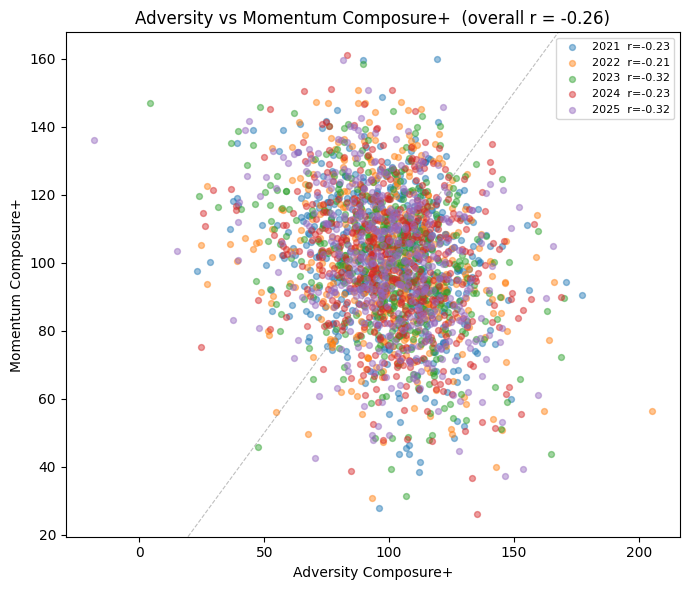

Overall Pearson r = -0.263  (n=2391 pitcher-seasons)


In [431]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ── Load all scored seasons ───────────────────────────────────────────────────
csvs = [os.path.join(RESULTS_DIR, f'composure_scores_{yr}.csv')
        for yr in SEASONS
        if os.path.exists(os.path.join(RESULTS_DIR, f'composure_scores_{yr}.csv'))]

if not csvs:
    print('No scored seasons found — run Phase 3 first.')
    all_df, seasons_present = pd.DataFrame(), []
else:
    all_df = pd.concat([pd.read_csv(p) for p in csvs], ignore_index=True)
    seasons_present = sorted(all_df['season'].unique())

    fig, ax = plt.subplots(figsize=(7, 6))
    colors = cm.tab10.colors

    for idx, yr in enumerate(seasons_present):
        sub = all_df[all_df['season'] == yr].dropna(
            subset=['adversity_composure_plus', 'momentum_composure_plus'])
        r = sub[['adversity_composure_plus', 'momentum_composure_plus']].corr().iloc[0, 1]
        ax.scatter(sub['adversity_composure_plus'], sub['momentum_composure_plus'],
                   alpha=0.45, s=18, color=colors[idx % 10], label=f'{yr}  r={r:.2f}')

    overall = all_df.dropna(subset=['adversity_composure_plus', 'momentum_composure_plus'])
    r_all = overall[['adversity_composure_plus', 'momentum_composure_plus']].corr().iloc[0, 1]
    ax.axline((100, 100), slope=1, color='grey', lw=0.8, ls='--', alpha=0.5)
    ax.set_xlabel('Adversity Composure+')
    ax.set_ylabel('Momentum Composure+')
    ax.set_title(f'Adversity vs Momentum Composure+  (overall r = {r_all:.2f})')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    print(f'Overall Pearson r = {r_all:.3f}  (n={len(overall)} pitcher-seasons)')


In [432]:
# Depends on all_df and seasons_present defined in Cell A above.
yoy_rows = []
for yr in seasons_present[:-1]:
    cols = ['pitcher_name', 'composure_plus', 'adversity_composure_plus', 'momentum_composure_plus']
    t0 = all_df[all_df['season'] == yr][cols].dropna()
    t1 = all_df[all_df['season'] == yr + 1][cols].dropna()
    merged = t0.merge(t1, on='pitcher_name', suffixes=('_t0', '_t1'))
    if len(merged) < 10:
        continue
    for col in ['composure_plus', 'adversity_composure_plus', 'momentum_composure_plus']:
        r = merged[[f'{col}_t0', f'{col}_t1']].corr().iloc[0, 1]
        yoy_rows.append({'seasons': f'{yr}\u2192{yr+1}', 'metric': col, 'r': round(r, 3), 'n': len(merged)})

if yoy_rows:
    yoy = pd.DataFrame(yoy_rows).pivot(index='seasons', columns='metric', values='r')
    yoy.columns.name = None
    print('Year-over-year Pearson r  (> 0.30 = repeatable skill  |  < 0.15 = mostly noise)\n')
    display(yoy)
else:
    print('Need at least 2 scored consecutive seasons for year-over-year analysis.')


Year-over-year Pearson r  (> 0.30 = repeatable skill  |  < 0.15 = mostly noise)



,adversity_composure_plus,composure_plus,momentum_composure_plus
seasons,,,
2021→2022,0.048,-0.032,0.032
2022→2023,0.127,0.134,0.087
2023→2024,-0.074,-0.070,-0.009
2024→2025,-0.067,0.020,0.026


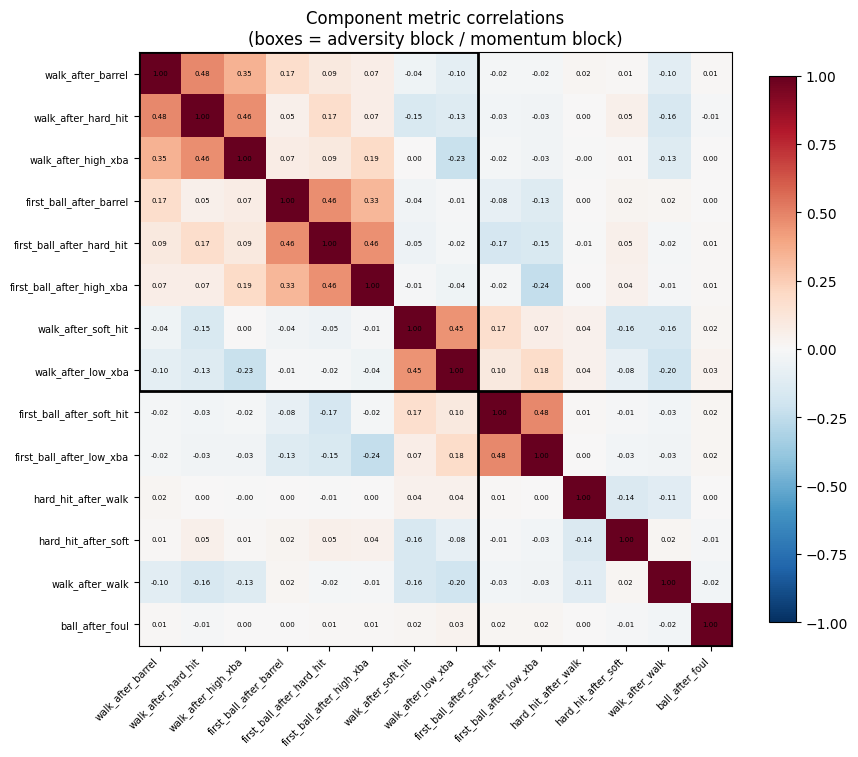

In [433]:
# Depends on seasons_present defined in Cell A above.
metric_dfs = []
for yr in seasons_present:
    path = os.path.join(DATA_DIR, f'pitcher_metrics_{yr}.parquet')
    if os.path.exists(path):
        df = pd.read_parquet(path)
        df = df[df['pitch_count'] >= MIN_PITCHES]
        metric_dfs.append(df[METRIC_COLS])

if not metric_dfs:
    print('No pitcher_metrics parquets found — run Phase 2 first.')
else:
    combined = pd.concat(metric_dfs, ignore_index=True).dropna(how='all')
    corr = combined.corr()

    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_xticks(range(len(METRIC_COLS)))
    ax.set_yticks(range(len(METRIC_COLS)))
    ax.set_xticklabels(METRIC_COLS, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(METRIC_COLS, fontsize=7)
    for i in range(len(METRIC_COLS)):
        for j in range(len(METRIC_COLS)):
            ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                    fontsize=5, color='black')
    # Draw boxes around adversity block and momentum block
    n_adv = len(ADVERSITY_METRICS)
    for block_start, block_size in [(0, n_adv), (n_adv, len(MOMENTUM_METRICS))]:
        rect = plt.Rectangle((block_start - 0.5, block_start - 0.5),
                               block_size, block_size,
                               fill=False, edgecolor='black', lw=2)
        ax.add_patch(rect)
    ax.set_title('Component metric correlations\n(boxes = adversity block / momentum block)')
    plt.tight_layout()
    plt.show()


In [434]:
# Depends on all_df defined in Cell A above.
DIVERGENCE_THRESHOLD = 10  # composure+ points

div = all_df.copy().dropna(subset=['adversity_composure_plus', 'momentum_composure_plus'])
div['divergence'] = div['adversity_composure_plus'] - div['momentum_composure_plus']
show_cols = ['season', 'pitcher_name', 'pitch_count',
             'composure_plus', 'adversity_composure_plus', 'momentum_composure_plus', 'divergence']

print('=== High adversity / low momentum  (bounces back from hard contact; coasts when lucky) ===')
display(
    div[div['divergence'] > DIVERGENCE_THRESHOLD][show_cols]
    .sort_values('divergence', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

print('\n=== High momentum / low adversity  (stays sharp when lucky; compounds bad events) ===')
display(
    div[div['divergence'] < -DIVERGENCE_THRESHOLD][show_cols]
    .sort_values('divergence')
    .head(15)
    .reset_index(drop=True)
)


=== High adversity / low momentum  (bounces back from hard contact; coasts when lucky) ===


,season,pitcher_name,pitch_count,composure_plus,adversity_composure_plus,momentum_composure_plus,divergence
0,2022,"dunning, dane",2548,131.000,205.300,56.300,149.000
1,2023,"irvin, jake",2149,92.400,164.900,43.900,121.000
2,2025,"civale, aaron",1748,82.300,153.800,39.500,114.300
3,2025,"miller, bryce",1545,74.700,146.300,37.200,109.100
4,2024,"jackson, luke",921,56.700,135.000,26.200,108.800
5,2022,"pérez, martín",2979,102.500,162.000,56.500,105.500
6,2022,"sánchez, aníbal",1240,75.500,142.900,40.100,102.800
7,2025,"senga, kodai",1908,106.300,159.500,61.000,98.500
8,2024,"glasnow, tyler",2012,95.100,152.700,55.600,97.100
9,2024,"ferguson, tyler",827,64.800,133.000,36.600,96.400



=== High momentum / low adversity  (stays sharp when lucky; compounds bad events) ===


,season,pitcher_name,pitch_count,composure_plus,adversity_composure_plus,momentum_composure_plus,divergence
0,2025,"peralta, freddy",3089,48.900,-18.300,136.000,-154.300
1,2023,"kopech, michael",2432,77.100,4.300,146.900,-142.600
2,2023,"johnson, pierce",1089,94.200,39.500,138.800,-99.300
3,2023,"rodriguez, grayson",2104,88.800,36.500,135.300,-98.800
4,2025,"wheeler, zack",2394,98.600,43.900,141.600,-97.700
5,2023,"abreu, albert",1055,107.400,48.400,145.900,-97.500
6,2025,"webb, logan",3282,95.100,42.400,139.000,-96.600
7,2021,"maeda, kenta",1776,91.700,38.900,135.300,-96.400
8,2023,"de los santos, enyel",1059,64.800,23.700,119.700,-96.000
9,2022,"montgomery, jordan",2715,71.700,26.900,122.600,-95.700


---
### External Validation — Composure+ vs Traditional Metrics

Correlates Composure+ with ERA, xBA against, and BB% to test whether the metric captures
signal beyond what established stats already measure.

- **ERA** and **BB%**: pulled from FanGraphs via `pitching_stats()`, joined on pitcher MLBAM → FanGraphs ID.
- **xBA against**: computed from `all_pitches_YYYY.parquet` (mean `estimated_ba_using_speedangle`
  on batted balls), joined on MLBAM ID directly — no external lookup needed.

In [ ]:
# ── External validation: Composure+ vs ERA, BB%, FIP ─────────────────────────
# All stats from MLB Stats API — same source as Phase 1. FIP computed from
# K, BB, HBP, HR, IP components with a season-specific FIP constant.

csvs = [os.path.join(RESULTS_DIR, f'composure_scores_{yr}.csv')
        for yr in SEASONS
        if os.path.exists(os.path.join(RESULTS_DIR, f'composure_scores_{yr}.csv'))]

if not csvs:
    print('No scored seasons found — run Phase 3 first.')
else:
    comp_df = pd.concat([pd.read_csv(p) for p in csvs], ignore_index=True)
    scored_seasons = sorted(comp_df['season'].unique())
    print(f'Loaded composure scores: {len(comp_df)} pitcher-seasons across {scored_seasons}')

    if 'pitcher_id' not in comp_df.columns:
        print('ERROR: pitcher_id column missing — re-run Phase 3 scoring cells first.')
    else:
        comp_df['pitcher_id'] = pd.to_numeric(comp_df['pitcher_id'], errors='coerce')

        def parse_ip(ip_str):
            """'6.2' → 6⅔ innings. Decimal part is outs (0/1/2), not tenths."""
            parts = str(ip_str).split('.')
            full = int(parts[0])
            outs = int(parts[1]) if len(parts) > 1 else 0
            return full + outs / 3.0

        def fetch_pitching(season):
            url = (f'https://statsapi.mlb.com/api/v1/stats'
                   f'?stats=season&group=pitching&season={season}'
                   f'&sportId=1&gameType=R&playerPool=All&limit=2000')
            splits = requests.get(url).json()['stats'][0]['splits']
            rows = []
            for s in splits:
                st = s['stat']
                ip  = parse_ip(st.get('inningsPitched', 0))
                bb  = int(st.get('baseOnBalls',    0))
                hbp = int(st.get('hitByPitch',     0))
                hr  = int(st.get('homeRuns',       0))
                k   = int(st.get('strikeOuts',     0))
                er  = int(st.get('earnedRuns',     0))
                bf  = int(st.get('battersFaced',   0))
                rows.append({
                    'pitcher_id': s['player']['id'],
                    'ERA':   (er * 9 / ip)     if ip > 0 else None,
                    'BB_pct': bb / bf          if bf > 0 else None,
                    'FIP_num': (13*hr + 3*(bb+hbp) - 2*k),  # numerator (no IP yet)
                    'IP':    ip,
                    'season': season,
                })
            df = pd.DataFrame(rows)
            # Season-specific FIP constant = lgERA - lgFIP_raw
            lg_ip  = df['IP'].sum()
            lg_er  = sum(int(s['stat'].get('earnedRuns', 0)) for s in splits)
            lg_num = df['FIP_num'].sum()
            if lg_ip > 0:
                fip_const = (lg_er * 9 / lg_ip) - (lg_num / lg_ip)
            else:
                fip_const = 3.15
            df['FIP'] = np.where(df['IP'] > 0,
                                 df['FIP_num'] / df['IP'] + fip_const,
                                 None)
            return df.drop(columns=['FIP_num'])

        # ── Fetch ERA / BB% / FIP from MLB Stats API ──────────────────────────
        stat_frames = []
        for yr in scored_seasons:
            try:
                df_yr = fetch_pitching(yr)
                stat_frames.append(df_yr)
                print(f'  {yr}: {len(df_yr)} pitchers | FIP const ≈ {(df_yr["FIP"] - df_yr["FIP_num"] if "FIP_num" in df_yr.columns else 0):.2f}')
                print(f'  {yr}: {len(df_yr)} pitchers fetched')
            except Exception as e:
                print(f'  {yr}: FAILED — {e}')
        stat_all = pd.concat(stat_frames, ignore_index=True) if stat_frames else pd.DataFrame()

        # ── Merge on MLBAM pitcher_id (direct — no lookup needed) ─────────────
        merged = comp_df.copy()
        if not stat_all.empty:
            stat_all['pitcher_id'] = pd.to_numeric(stat_all['pitcher_id'], errors='coerce')
            merged = merged.merge(stat_all, on=['pitcher_id', 'season'], how='inner')
            print(f'After merge: {len(merged)} pitcher-seasons')

        for col in ['ERA', 'BB_pct', 'FIP']:
            if col in merged.columns:
                merged[col] = pd.to_numeric(merged[col], errors='coerce')

        avail = [c for c in ['ERA', 'BB_pct', 'FIP'] if c in merged.columns]
        print(f'\nMerged dataset: {len(merged)} pitcher-seasons | metrics: {avail}')
        if avail:
            display(merged[['pitcher_name', 'season', 'composure_plus'] + avail].head(10))


In [ ]:
# ── Scatter plots: Composure+ vs ERA, BB%, FIP ───────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

if 'merged' not in dir() or merged.empty:
    print('Run the merge cell above first.')
else:
    comparisons = [
        ('ERA',    'ERA (lower = better)'),
        ('BB_pct', 'BB% (lower = better)'),
        ('FIP',    'FIP (lower = better)'),
    ]
    comparisons = [(col, lbl) for col, lbl in comparisons if col in merged.columns]

    if not comparisons:
        print('No external metric columns available.')
    else:
        fig, axes = plt.subplots(1, len(comparisons), figsize=(6 * len(comparisons), 5))
        if len(comparisons) == 1:
            axes = [axes]
        fig.suptitle('Composure+ vs Traditional Pitching Metrics', fontsize=13, y=1.02)

        all_seasons_u = sorted(merged['season'].unique())
        season_colors = {yr: plt.cm.tab10.colors[i % 10] for i, yr in enumerate(all_seasons_u)}

        for ax, (col, xlabel) in zip(axes, comparisons):
            sub = merged[['composure_plus', col, 'season']].dropna()
            if sub.empty:
                ax.set_title(f'{col}: no data')
                ax.set_xlabel(xlabel, fontsize=9)
                continue

            x, y = sub[col], sub['composure_plus']
            r = sub[[col, 'composure_plus']].corr().iloc[0, 1]

            for yr in all_seasons_u:
                mask = sub['season'] == yr
                if mask.any():
                    ax.scatter(x[mask], y[mask], alpha=0.35, s=16,
                               color=season_colors[yr], label=str(yr))

            m, b = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 100)
            ax.plot(x_line, m * x_line + b, color='black', lw=1.2, ls='--')

            ax.axhline(100, color='grey', lw=0.6, ls=':', label='League avg')
            ax.set_xlabel(xlabel, fontsize=9)
            if ax is axes[0]:
                ax.set_ylabel('Composure+', fontsize=9)
            ax.set_title(f'r = {r:.3f}  (n={len(sub)})', fontsize=10)
            ax.legend(fontsize=7, markerscale=1.5, loc='upper right')

        plt.tight_layout()
        plt.show()

        print('\nCorrelation with Composure+:')
        print(f'  {"Metric":<24} {"r":>7}  {"n":>6}')
        print(f'  {"-"*40}')
        for col, label in comparisons:
            sub = merged[['composure_plus', col]].dropna()
            r   = sub.corr().iloc[0, 1]
            print(f'  {label:<24} {r:>+7.3f}  {len(sub):>6}')


In [ ]:
# ── Partial correlation: does Composure+ predict FIP beyond what BB% explains? ─
from numpy.linalg import lstsq
import matplotlib.pyplot as plt
import numpy as np

if 'merged' not in dir() or merged.empty:
    print('Run the merge cell first.')
elif 'BB_pct' not in merged.columns or 'FIP' not in merged.columns:
    print('BB_pct or FIP missing from merged — check cell 29 output.')
else:
    sub = merged[['FIP', 'ERA', 'BB_pct', 'composure_plus', 'pitcher_name', 'season']].dropna()
    bb   = sub['BB_pct'].values
    comp = sub['composure_plus'].values
    fip  = sub['FIP'].values
    era  = sub['ERA'].values

    def ols_residuals(y, *controls):
        X = np.column_stack([np.ones(len(y))] + list(controls))
        beta = lstsq(X, y, rcond=None)[0]
        return y - X @ beta

    def r2(y, *controls):
        resid = ols_residuals(y, *controls)
        return 1 - resid.var() / y.var()

    # ── Key numbers ──────────────────────────────────────────────────────────
    r_fip_bb    = np.corrcoef(fip,  bb)[0, 1]
    r_fip_comp  = np.corrcoef(fip,  comp)[0, 1]
    r_era_bb    = np.corrcoef(era,  bb)[0, 1]
    r_era_comp  = np.corrcoef(era,  comp)[0, 1]
    r_bb_comp   = np.corrcoef(bb,   comp)[0, 1]

    fip_resid   = ols_residuals(fip,  bb)
    comp_resid  = ols_residuals(comp, bb)
    partial_r   = np.corrcoef(fip_resid, comp_resid)[0, 1]

    r2_bb_only  = r2(fip, bb)
    r2_bb_comp  = r2(fip, bb, comp)
    delta_r2    = r2_bb_comp - r2_bb_only

    print('── Bivariate correlations ───────────────────────────────────')
    print(f'  FIP vs BB%:          r = {r_fip_bb:+.3f}')
    print(f'  FIP vs Composure+:   r = {r_fip_comp:+.3f}')
    print(f'  ERA vs BB%:          r = {r_era_bb:+.3f}')
    print(f'  ERA vs Composure+:   r = {r_era_comp:+.3f}')
    print(f'  BB% vs Composure+:   r = {r_bb_comp:+.3f}')
    print()
    print('── Partial correlation (Composure+ -> FIP | controlling for BB%) ─')
    print(f'  Partial r:           {partial_r:+.3f}')
    print()
    print('── Incremental R² (target: FIP) ─────────────────────────────')
    print(f'  FIP ~ BB% alone:             R² = {r2_bb_only:.3f}')
    print(f'  FIP ~ BB% + Composure+:      R² = {r2_bb_comp:.3f}')
    print(f'  Composure+ adds:          dR² = {delta_r2:+.3f}  ({delta_r2*100:.1f} pp)')
    print()
    if abs(partial_r) >= 0.15:
        print(f'  Composure+ adds meaningful signal beyond BB% (partial r = {partial_r:+.3f})')
    else:
        print(f'  Composure+ adds little signal beyond BB% (partial r = {partial_r:+.3f})')

    # ── Two-panel plot: raw FIP vs residualised ───────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Partial correlation: Composure+ vs FIP, controlling for BB%', fontsize=12)

    all_seasons = sorted(sub['season'].unique())
    season_colors = {yr: plt.cm.tab10.colors[i % 10] for i, yr in enumerate(all_seasons)}

    ax = axes[0]
    for yr in all_seasons:
        mask = sub['season'] == yr
        ax.scatter(sub.loc[mask, 'composure_plus'], sub.loc[mask, 'FIP'],
                   alpha=0.35, s=14, color=season_colors[yr], label=str(yr))
    m, b_coef = np.polyfit(comp, fip, 1)
    xs = np.linspace(comp.min(), comp.max(), 100)
    ax.plot(xs, m*xs + b_coef, 'k--', lw=1.2)
    ax.set_xlabel('Composure+', fontsize=9)
    ax.set_ylabel('FIP', fontsize=9)
    ax.set_title(f'Raw: r = {r_fip_comp:.3f}  (n={len(sub)})', fontsize=10)
    ax.legend(fontsize=7)

    ax = axes[1]
    for i, yr in enumerate(all_seasons):
        mask = (sub['season'] == yr).values
        ax.scatter(comp_resid[mask], fip_resid[mask],
                   alpha=0.35, s=14, color=season_colors[yr], label=str(yr))
    m2, b2 = np.polyfit(comp_resid, fip_resid, 1)
    xs2 = np.linspace(comp_resid.min(), comp_resid.max(), 100)
    ax.plot(xs2, m2*xs2 + b2, 'k--', lw=1.2)
    ax.axhline(0, color='grey', lw=0.6, ls=':')
    ax.axvline(0, color='grey', lw=0.6, ls=':')
    ax.set_xlabel('Composure+ residual (BB% removed)', fontsize=9)
    ax.set_ylabel('FIP residual (BB% removed)', fontsize=9)
    ax.set_title(f'Partial: r = {partial_r:.3f}  dR² = {delta_r2:.3f}', fontsize=10)
    ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()
